# High-Dimensional Perceptron Memorization on AFHQ

This notebook studies a simple question: can a linear perceptron memorize random labels on real cat/dog images when each image has thousands of pixel features?

The short answer is yes, up to a point. A 64 x 64 grayscale image has 4096 pixel features. With a bias term, the linear classifier has 4097 adjustable degrees of freedom. That high dimensionality can allow perfect training-set fits even when the labels are random.

## Why Randomize The Labels?

The experiment starts with real cat and dog face images from AFHQ, but then replaces the true labels with random `-1` and `+1` labels.

That makes the interpretation clean:

- If the classifier fits the randomized labels, it is memorizing.
- It cannot be learning the visual concept of cat versus dog, because the labels no longer mean cat or dog.
- This is a compact way to demonstrate why perfect training accuracy can be misleading in high dimensions.

## Experiment Plan

1. Load AFHQ cat/dog images.
2. Resize each image to 64 x 64 grayscale.
3. Flatten each image into a 4096-dimensional vector.
4. Randomize the labels.
5. Test sample sizes below, at, and above `4097`.
6. Compare an exact linear construction with finite perceptron training.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from IPython.display import Image, display

from afhq_vc_demo.config import BIAS_DIM, IMAGE_SIZE, INPUT_DIM, KAGGLE_SLUG
from afhq_vc_demo.data import find_class_dirs, load_afhq_cat_dog, make_synthetic_vectors
from afhq_vc_demo.experiment import run_experiments
from afhq_vc_demo.reporting import write_outputs

DATA_ROOT = PROJECT_ROOT / "data" / "raw"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
SAMPLE_SIZES = [500, 1000, 2000, 4096, 4097, 5000]
SEED = 7
MAX_EPOCHS = 50

print(f"Dataset handle: {KAGGLE_SLUG}")
print(f"Image size: {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Input dimension: {INPUT_DIM}; with bias: {BIAS_DIM}")

Dataset handle: andrewmvd/animal-faces
Image size: 64 x 64
Input dimension: 4096; with bias: 4097


## Data Availability

The project expects AFHQ under `data/raw`. If it is not present, run this from the repository root:

```bash
python scripts/download_afhq.py --source kagglehub
```

If KaggleHub is unavailable, the script also supports `--source kaggle` and `--source official`.

In [2]:
cat_dir, dog_dir = find_class_dirs(DATA_ROOT)
cat_count = sum(1 for p in cat_dir.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"})
dog_count = sum(1 for p in dog_dir.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"})
print(f"Cat images available: {cat_count}")
print(f"Dog images available: {dog_count}")

Cat images available: 5153
Dog images available: 4739


## Load 64 x 64 Grayscale Vectors

The loader shuffles the images, converts them to grayscale, resizes them to 64 x 64, flattens them, and standardizes the pixel features.

In [3]:
x, true_labels, paths = load_afhq_cat_dog(DATA_ROOT, max(SAMPLE_SIZES), SEED)
print(f"Feature matrix shape: {x.shape}")
print(f"Loaded examples: {len(paths)}")
print(f"True-label balance in loaded sample: cats={(true_labels == -1).sum()}, dogs={(true_labels == 1).sum()}")

Loading AFHQ images:   0%|          | 0/5000 [00:00<?, ?it/s]

Loading AFHQ images:   1%|          | 59/5000 [00:00<00:08, 581.58it/s]

Loading AFHQ images:   2%|▏         | 123/5000 [00:00<00:07, 610.54it/s]

Loading AFHQ images:   4%|▎         | 186/5000 [00:00<00:07, 618.14it/s]

Loading AFHQ images:   5%|▍         | 248/5000 [00:00<00:07, 613.45it/s]

...

Loading AFHQ images:  96%|█████████▌| 4812/5000 [00:07<00:00, 639.14it/s]

Loading AFHQ images:  98%|█████████▊| 4877/5000 [00:07<00:00, 641.36it/s]

Loading AFHQ images:  99%|█████████▉| 4942/5000 [00:07<00:00, 640.48it/s]

Loading AFHQ images: 100%|██████████| 5000/5000 [00:07<00:00, 631.07it/s]

Feature matrix shape: (5000, 4096)
Loaded examples: 5000
True-label balance in loaded sample: cats=2593, dogs=2407


## Run The Randomized-Label Experiment

The true labels are not used for training here. `run_experiments` creates a fixed random labeling from the seed and evaluates the same randomized split for each sample size.

In [4]:
results = run_experiments(x, SAMPLE_SIZES, max_epochs=MAX_EPOCHS, seed=SEED)
write_outputs(results, OUTPUT_ROOT, source_name="Kaggle AFHQ dataset (andrewmvd/animal-faces), local data/raw")

for result in results:
    print(result)

ExperimentResult(sample_size=500, rank_with_bias=500, vc_solution_train_error=0.0, perceptron_train_error=0.0, perceptron_epochs=48, perceptron_updates=2638, perceptron_converged=True)
ExperimentResult(sample_size=1000, rank_with_bias=1000, vc_solution_train_error=0.0, perceptron_train_error=0.034, perceptron_epochs=50, perceptron_updates=8196, perceptron_converged=False)
ExperimentResult(sample_size=2000, rank_with_bias=2000, vc_solution_train_error=0.0, perceptron_train_error=0.1585, perceptron_epochs=50, perceptron_updates=24828, perceptron_converged=False)
ExperimentResult(sample_size=4096, rank_with_bias=4096, vc_solution_train_error=0.0, perceptron_train_error=0.29248046875, perceptron_epochs=50, perceptron_updates=67358, perceptron_converged=False)
ExperimentResult(sample_size=4097, rank_with_bias=4097, vc_solution_train_error=0.0, perceptron_train_error=0.25628508664876737, perceptron_epochs=50, perceptron_updates=67786, perceptron_converged=False)
ExperimentResult(sample_size=

## Results Table

In [5]:
import pandas as pd

df = pd.DataFrame([r.__dict__ for r in results])
df

,sample_size,rank_with_bias,vc_solution_train_error,perceptron_train_error,perceptron_epochs,perceptron_updates,perceptron_converged
0,500,500,0.0000,0.000000,48,2638,True
1,1000,1000,0.0000,0.034000,50,8196,False
2,2000,2000,0.0000,0.158500,50,24828,False
3,4096,4096,0.0000,0.292480,50,67358,False
4,4097,4097,0.0000,0.256285,50,67786,False
5,5000,4097,0.0262,0.225200,50,86708,False


## Figures

training_error.png


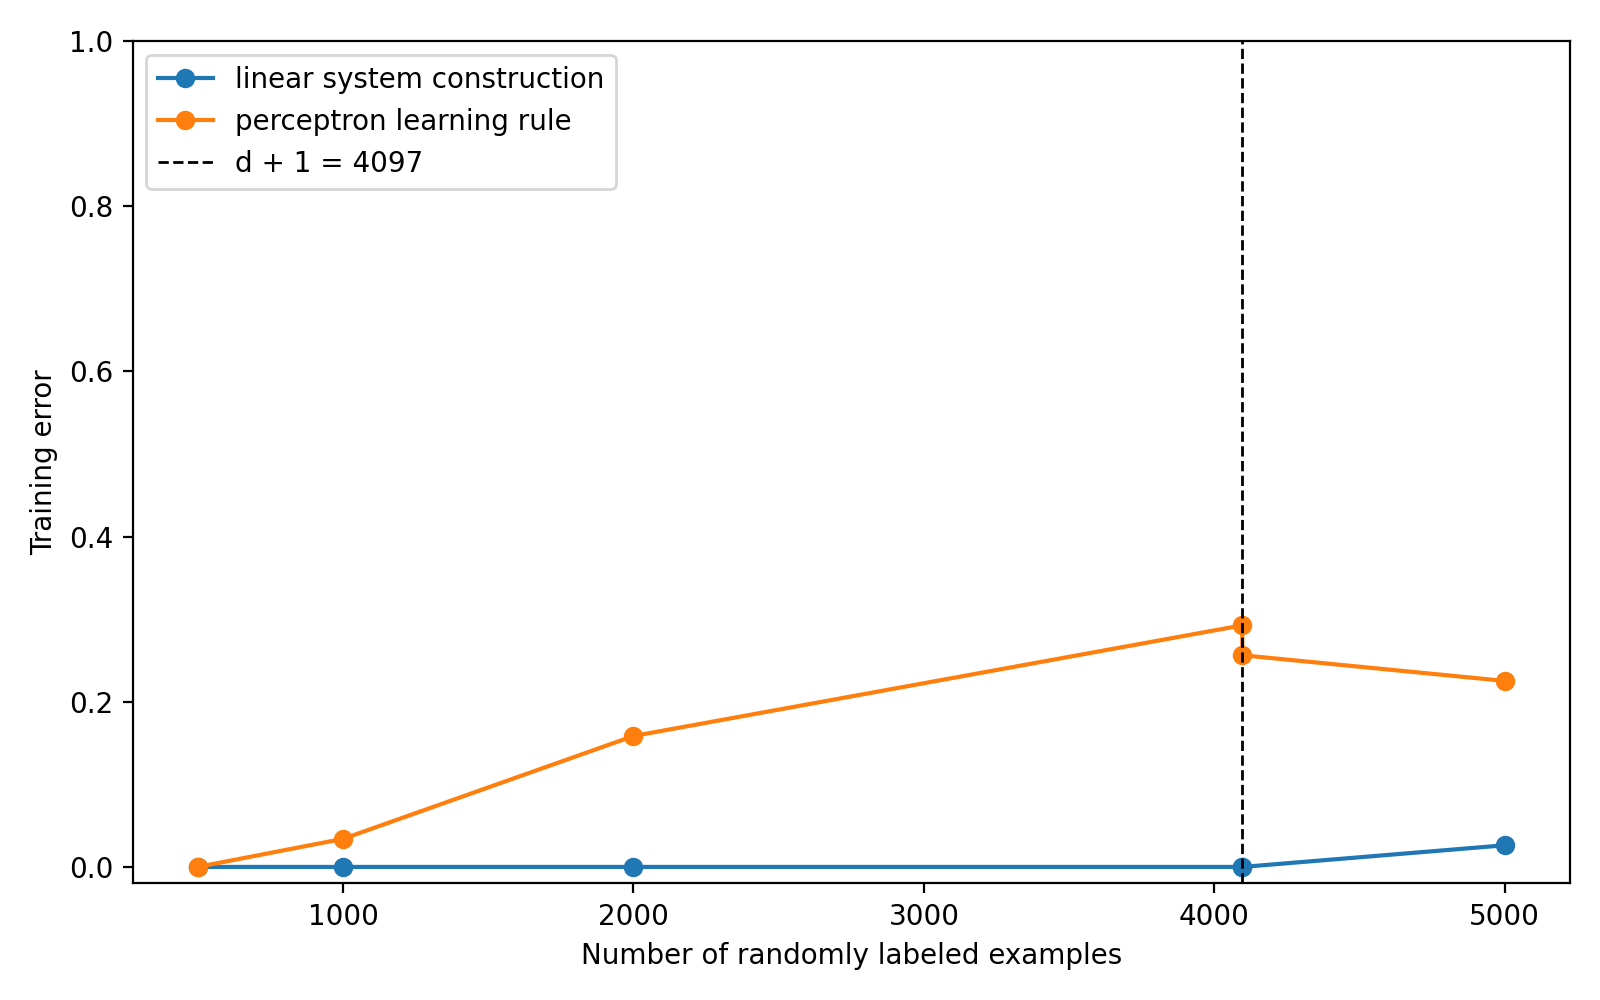

rank_vs_sample_size.png


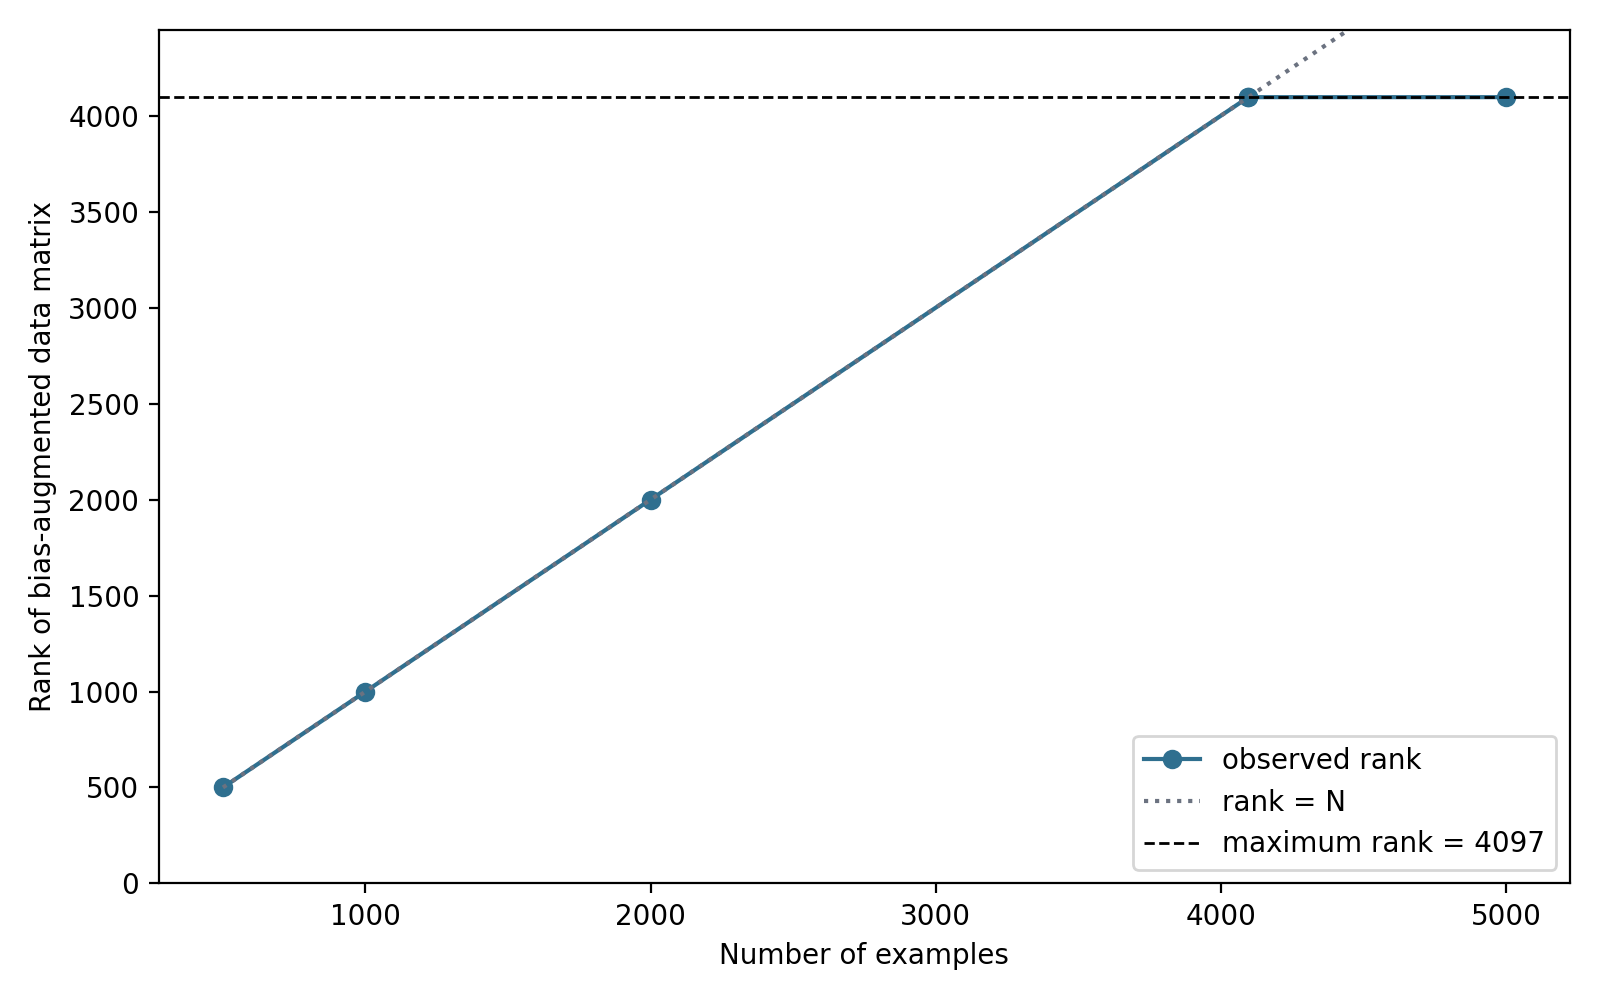

perceptron_updates.png


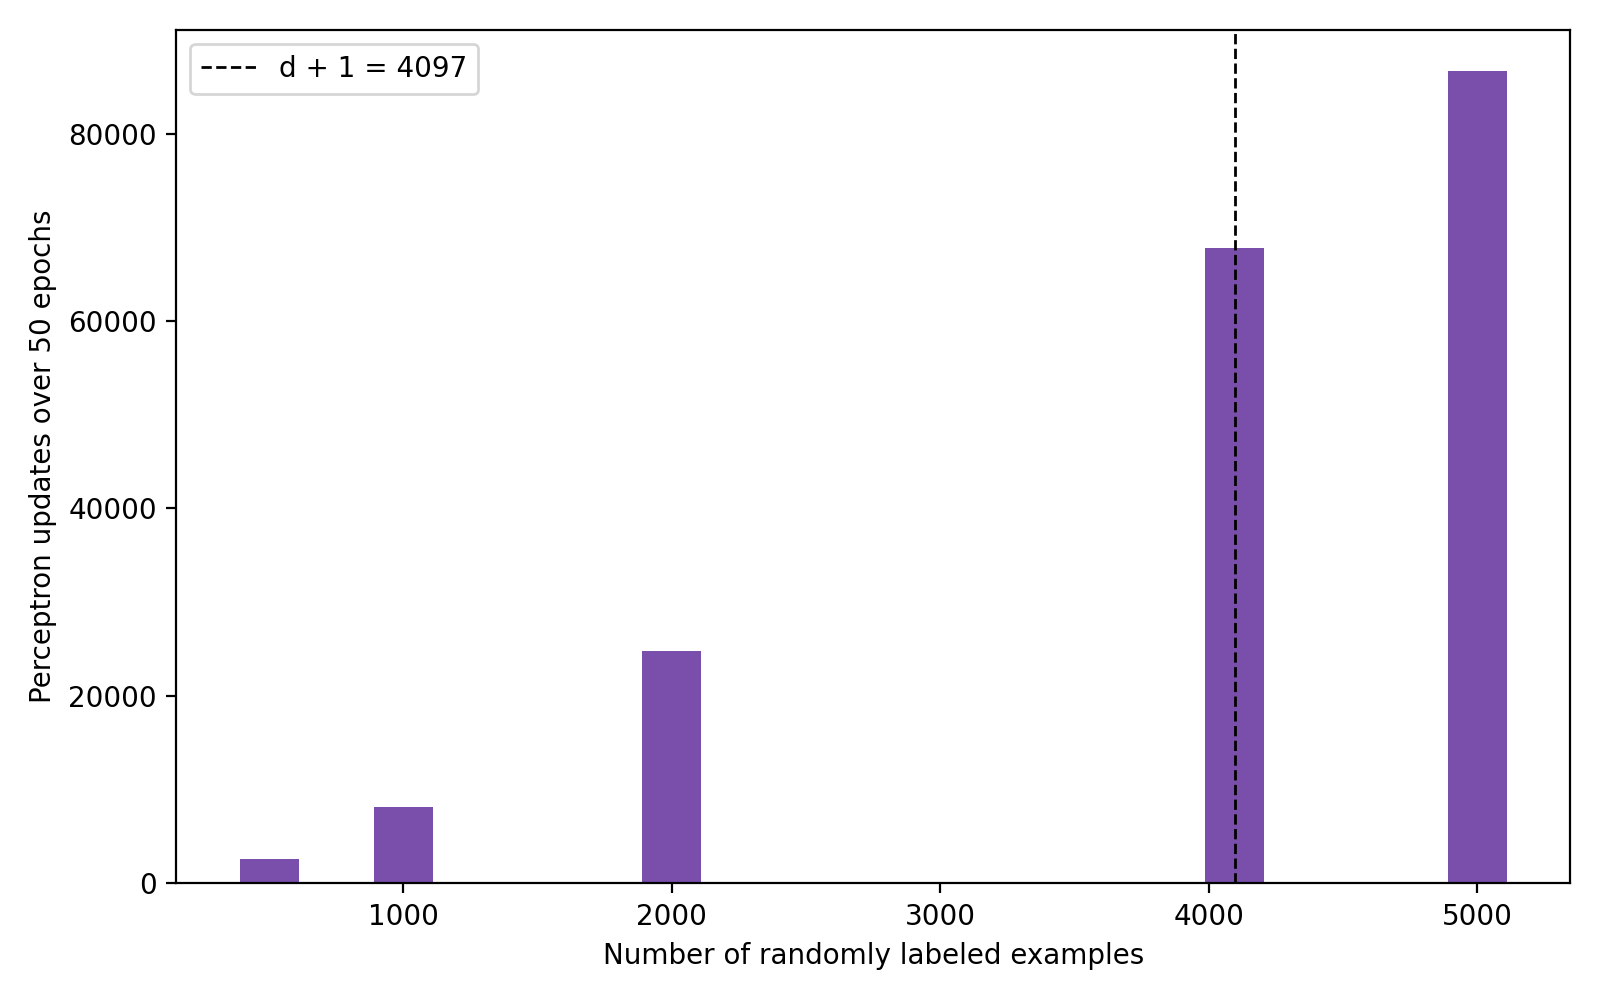

In [6]:
for name in ["training_error.png", "rank_vs_sample_size.png", "perceptron_updates.png"]:
    print(name)
    display(Image(filename=str(OUTPUT_ROOT / "figures" / name)))

## How To Read This

The exact linear construction reaches zero error through `N = 4097`, which is the bias-augmented dimension of the 64 x 64 image vectors. At `N = 5000`, the rank is still capped at 4097 and the exact construction no longer fits every random label.

The perceptron training run is different. It only reached zero error for `N = 500` within 50 epochs. That does not contradict the exact construction. It means that even when a separator exists, this particular training procedure may not find it quickly.

The main lesson is that high-dimensional models can fit training labels for reasons that have nothing to do with understanding the real visual categories.

## Small Synthetic Smoke Test

This tiny synthetic run is included only to verify the code path quickly. The real result above uses AFHQ images.

In [7]:
SMOKE_SAMPLE_SIZES = [20, 40, 80]
x_synth, _ = make_synthetic_vectors(max(SMOKE_SAMPLE_SIZES), SEED)
synthetic_results = run_experiments(x_synth, SMOKE_SAMPLE_SIZES, max_epochs=10, seed=SEED)
for result in synthetic_results:
    print(result)

ExperimentResult(sample_size=20, rank_with_bias=20, vc_solution_train_error=0.0, perceptron_train_error=0.0, perceptron_epochs=2, perceptron_updates=14, perceptron_converged=True)
ExperimentResult(sample_size=40, rank_with_bias=40, vc_solution_train_error=0.0, perceptron_train_error=0.0, perceptron_epochs=2, perceptron_updates=26, perceptron_converged=True)
ExperimentResult(sample_size=80, rank_with_bias=80, vc_solution_train_error=0.0, perceptron_train_error=0.0, perceptron_epochs=3, perceptron_updates=40, perceptron_converged=True)
